In [1]:

LOAD_DIR = "msaa_outputs_npz"
K_VALUES = [10, 25, 50, 75, 100]

NFOLDS_DECODE = 2
NREPS_DECODE = 50
TOP_M_LIST = [1, 2, 3, 4, 5]
RNG_SEED = 42

ERRORBAR_TYPE = "std"   # "sem", "std", or "ci95"

COND_PLOT_COLORS = {
    "intact": "purple",
    "word": "green",
    "rest": "black",
}



# 02_decoding_analysis_from_npz_updated.ipynb

Run this second.

This updated notebook does four main decoding analyses for **each K**:

1. **Full reconstruction decoding by condition**
   - reconstruct with **all archetypes**
   - decode separately for `intact`, `word`, and `rest`

2. **Top-m global-archetype decoding by condition**
   - rank archetypes globally within each K
   - reconstruct with the top `m` archetypes
   - decode separately for each condition

3. **Top clustering-archetype decoding by condition**
   - paste in the top clustering archetypes from Notebook 3
   - reconstruct with just those archetypes
   - decode separately for each condition

4. Plot all of the above across **all K values**, with **error bars**
   - default error bars are **SEM across rep × fold runs**


In [2]:

%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

print("Ready.")


Ready.


In [3]:

def load_msaa_npz(path):
    data = np.load(path, allow_pickle=True)
    results_subj = data["results_subj"].tolist()
    if isinstance(results_subj, np.ndarray):
        results_subj = results_subj.tolist()

    return {
        "K": int(data["K"]),
        "results_subj": results_subj,
        "condition_labels_str": data["condition_labels_str"].tolist(),
        "condition_codes": data["condition_codes"],
        "condition_names": data["condition_names"].tolist(),
    }

loaded = {}
for K in K_VALUES:
    path = os.path.join(LOAD_DIR, f"spatialAA_acrossCond_K{K}.npz")
    loaded[K] = load_msaa_npz(path)
    print("Loaded:", path)


Loaded: msaa_outputs_npz/spatialAA_acrossCond_K10.npz
Loaded: msaa_outputs_npz/spatialAA_acrossCond_K25.npz
Loaded: msaa_outputs_npz/spatialAA_acrossCond_K50.npz
Loaded: msaa_outputs_npz/spatialAA_acrossCond_K75.npz
Loaded: msaa_outputs_npz/spatialAA_acrossCond_K100.npz


## Decoding helpers

In [4]:

def decoder(corrs):
    out = pd.DataFrame({'rank':[0.0], 'accuracy':[0.0], 'error':[0.0]})
    T = corrs.shape[0]
    for t in range(T):
        decoded_ind = int(np.argmax(corrs[t, :]))
        out.loc[0, 'error'] += np.mean(np.abs(decoded_ind - t)) / T
        out.loc[0, 'accuracy'] += (decoded_ind == t)
        out.loc[0, 'rank'] += np.mean((corrs[t, :] <= corrs[t, t]).astype(int))
    out['error'] /= T
    out['accuracy'] /= T
    out['rank'] /= T
    return out

def get_xval_assignments(ndata, nfolds, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    group_assignments = np.zeros(ndata, dtype=int)
    groupsize = int(np.ceil(ndata / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * groupsize, min((i + 1) * groupsize, ndata))
        group_assignments[inds] = i
    rng.shuffle(group_assignments)
    return group_assignments

def build_coeff_recon_stack(subjects, top_indices=None):
    Xhats = []
    for sub in subjects:
        sXC = np.asarray(sub["sXC"], dtype=float)
        S = np.asarray(sub["S"], dtype=float)

        if top_indices is None:
            Xhat = sXC @ S
        else:
            Xhat = sXC[:, top_indices] @ S[top_indices, :]

        Xhat = (Xhat - Xhat.mean(axis=0, keepdims=True)) / (Xhat.std(axis=0, keepdims=True) + 1e-8)
        Xhats.append(Xhat)

    return np.stack(Xhats, axis=0)

def run_timepoint_decoding(recon_stack, nfolds=2, nreps=20, seed=42):
    N, T, V = recon_stack.shape
    rng = np.random.default_rng(seed)
    all_results = []

    for rep in range(nreps):
        fold_ids = get_xval_assignments(N, nfolds, rng=rng)
        for i in range(nfolds):
            in_mask = (fold_ids == i)
            out_mask = ~in_mask

            in_mean = recon_stack[in_mask].mean(axis=0)
            out_mean = recon_stack[out_mask].mean(axis=0)

            corrs = 1.0 - cdist(in_mean, out_mean, metric='correlation')
            res = decoder(corrs)
            res["rep"] = rep
            res["fold"] = i
            all_results.append(res)

    return pd.concat(all_results, ignore_index=True)

def per_archetype_coeff_decoding(subjects, nfolds=2, nreps=20, seed=42):
    K = np.asarray(subjects[0]["S"]).shape[0]
    rows = []

    for k in range(K):
        recon_stack = build_coeff_recon_stack(subjects, top_indices=[k])
        res = run_timepoint_decoding(recon_stack, nfolds=nfolds, nreps=nreps, seed=seed)
        res["archetype"] = k
        rows.append(res)

    return pd.concat(rows, ignore_index=True)

def run_timepoint_decoding_topm(subjects, ranked_indices, top_ms=[1,2,3,4,5], nfolds=2, nreps=20, seed=42):
    rows = []
    for m in top_ms:
        top_idx = ranked_indices[:m]
        recon_stack = build_coeff_recon_stack(subjects, top_indices=top_idx)
        res = run_timepoint_decoding(recon_stack, nfolds=nfolds, nreps=nreps, seed=seed)
        res["top_m"] = m
        rows.append(res)
    return pd.concat(rows, ignore_index=True)

def subjects_for_condition(results_subj, condition_labels_str, cond_name):
    idx = np.where(np.asarray(condition_labels_str) == cond_name)[0]
    return [results_subj[i] for i in idx], idx



## Important note on what is being decoded

All decoding in this notebook is based on **reconstructed data in node space**.

For each subject:
- full reconstruction uses `Xhat = sXC @ S`
- top-m reconstruction uses `Xhat = sXC[:, top_indices] @ S[top_indices, :]`
- top clustering-archetype reconstruction uses the same kind of partial reconstruction

So the decoding is **not** being done directly on archetypes alone or on coefficients alone.  
It is always done on the reconstructed data matrix after projecting back into node space.


## Error bar helpers

In [7]:

def summarize_metric_with_error(df, metric_col, errorbar_type="sem", group_cols=None):
    if group_cols is None:
        group_cols = []

    out = (
        df.groupby(group_cols)[metric_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    if errorbar_type == "sem":
        out["err"] = out["std"] / np.sqrt(out["count"].clip(lower=1))
    elif errorbar_type == "std":
        out["err"] = out["std"]
    elif errorbar_type == "ci95":
        out["err"] = 1.96 * out["std"] / np.sqrt(out["count"].clip(lower=1))
    else:
        raise ValueError("errorbar_type must be 'sem', 'std', or 'ci95'")

    return out


## Full reconstruction decoding by condition for each K

In [8]:

full_recon_rows = []

for K in K_VALUES:
    cur = loaded[K]
    results_subj = cur["results_subj"]
    condition_labels_str = np.array(cur["condition_labels_str"])

    for cond_name in np.unique(condition_labels_str):
        sub_cond, idx = subjects_for_condition(results_subj, condition_labels_str, cond_name)
        recon_stack = build_coeff_recon_stack(sub_cond, top_indices=None)
        res = run_timepoint_decoding(
            recon_stack,
            nfolds=NFOLDS_DECODE,
            nreps=NREPS_DECODE,
            seed=RNG_SEED,
        )
        res["K"] = K
        res["condition"] = cond_name
        res["reconstruction"] = "all_archetypes"
        full_recon_rows.append(res)

full_recon_df = pd.concat(full_recon_rows, ignore_index=True)
display(full_recon_df.head())


,rank,accuracy,error,rep,fold,K,condition,reconstruction
0,0.817333,0.053333,0.239011,0,0,10,intact,all_archetypes
1,0.816256,0.043333,0.286489,0,1,10,intact,all_archetypes
2,0.829378,0.043333,0.272811,1,0,10,intact,all_archetypes
3,0.831289,0.056667,0.265389,1,1,10,intact,all_archetypes
4,0.836822,0.033333,0.292711,2,0,10,intact,all_archetypes


## Top-m global archetype decoding by condition for each K

In [9]:

topm_rows = []
global_rankings = {}

for K in K_VALUES:
    cur = loaded[K]
    results_subj = cur["results_subj"]
    condition_labels_str = np.array(cur["condition_labels_str"])

    # global ranking across all subjects/conditions for this K
    per_arch_all = per_archetype_coeff_decoding(
        results_subj,
        nfolds=NFOLDS_DECODE,
        nreps=NREPS_DECODE,
        seed=RNG_SEED,
    )
    top_arch_global = (
        per_arch_all.groupby("archetype")["accuracy"]
        .mean()
        .sort_values(ascending=False)
    )
    global_rankings[K] = top_arch_global.index.to_numpy()

    for cond_name in np.unique(condition_labels_str):
        sub_cond, idx = subjects_for_condition(results_subj, condition_labels_str, cond_name)

        res = run_timepoint_decoding_topm(
            sub_cond,
            ranked_indices=global_rankings[K],
            top_ms=TOP_M_LIST,
            nfolds=NFOLDS_DECODE,
            nreps=NREPS_DECODE,
            seed=RNG_SEED,
        )
        res["K"] = K
        res["condition"] = cond_name
        res["reconstruction"] = "top_m_global"
        topm_rows.append(res)

topm_df = pd.concat(topm_rows, ignore_index=True)
display(topm_df.head())


,rank,accuracy,error,rep,fold,top_m,K,condition,reconstruction
0,0.651833,0.006667,0.327856,0,0,1,10,intact,top_m_global
1,0.650456,0.003333,0.356800,0,1,1,10,intact,top_m_global
2,0.687211,0.006667,0.309056,1,0,1,10,intact,top_m_global
3,0.690178,0.006667,0.347489,1,1,1,10,intact,top_m_global
4,0.661911,0.006667,0.313489,2,0,1,10,intact,top_m_global


## Save the top-m archetype identities so they can be plotted later

In [10]:

topm_archetype_rows = []

for K in K_VALUES:
    ranking = global_rankings[K]
    for m in TOP_M_LIST:
        selected = ranking[:m].tolist()
        topm_archetype_rows.append({
            "K": K,
            "top_m": m,
            "selected_archetypes": selected,
            "selected_archetypes_str": str(selected),
        })

topm_archetypes_df = pd.DataFrame(topm_archetype_rows)
display(topm_archetypes_df)


,K,top_m,selected_archetypes,selected_archetypes_str
0,10,1,[3],[3]
1,10,2,"[3, 2]","[3, 2]"
2,10,3,"[3, 2, 1]","[3, 2, 1]"
3,10,4,"[3, 2, 1, 0]","[3, 2, 1, 0]"
4,10,5,"[3, 2, 1, 0, 4]","[3, 2, 1, 0, 4]"
5,25,1,[2],[2]
6,25,2,"[2, 5]","[2, 5]"
7,25,3,"[2, 5, 7]","[2, 5, 7]"
8,25,4,"[2, 5, 7, 4]","[2, 5, 7, 4]"
9,25,5,"[2, 5, 7, 4, 8]","[2, 5, 7, 4, 8]"


In [12]:

# Paste the output from Notebook 3 here
TOP_CLUSTER_ARCHES_BY_K = {
10: [3, 2, 5], 25: [2, 5, 4], 50: [4, 8, 5], 75: [7, 6, 10], 100: [7, 9, 8]
}


In [13]:

cluster_recon_rows = []

for K, top_ks in TOP_CLUSTER_ARCHES_BY_K.items():
    if K not in loaded:
        continue

    cur = loaded[K]
    results_subj = cur["results_subj"]
    condition_labels_str = np.array(cur["condition_labels_str"])

    for cond_name in np.unique(condition_labels_str):
        sub_cond, idx = subjects_for_condition(results_subj, condition_labels_str, cond_name)
        recon_stack = build_coeff_recon_stack(sub_cond, top_indices=top_ks)
        res = run_timepoint_decoding(
            recon_stack,
            nfolds=NFOLDS_DECODE,
            nreps=NREPS_DECODE,
            seed=RNG_SEED,
        )
        res["K"] = K
        res["condition"] = cond_name
        res["reconstruction"] = "top_cluster_archetypes"
        res["top_cluster_ks"] = str(top_ks)
        cluster_recon_rows.append(res)

if len(cluster_recon_rows) > 0:
    cluster_recon_df = pd.concat(cluster_recon_rows, ignore_index=True)
else:
    cluster_recon_df = pd.DataFrame()

display(cluster_recon_df.head() if len(cluster_recon_df) > 0 else cluster_recon_df)


,rank,accuracy,error,rep,fold,K,condition,reconstruction,top_cluster_ks
0,0.725922,0.020000,0.308989,0,0,10,intact,top_cluster_archetypes,"[3, 2, 5]"
1,0.722289,0.013333,0.333278,0,1,10,intact,top_cluster_archetypes,"[3, 2, 5]"
2,0.739489,0.023333,0.262567,1,0,10,intact,top_cluster_archetypes,"[3, 2, 5]"
3,0.753578,0.033333,0.323944,1,1,10,intact,top_cluster_archetypes,"[3, 2, 5]"
4,0.719189,0.026667,0.297800,2,0,10,intact,top_cluster_archetypes,"[3, 2, 5]"


## Top clustering-archetype decoding by condition for each K

## Summaries

In [14]:

full_summary = summarize_metric_with_error(
    full_recon_df,
    metric_col="accuracy",
    errorbar_type=ERRORBAR_TYPE,
    group_cols=["K", "condition", "reconstruction"]
)
display(full_summary)

topm_summary = summarize_metric_with_error(
    topm_df,
    metric_col="accuracy",
    errorbar_type=ERRORBAR_TYPE,
    group_cols=["K", "condition", "reconstruction", "top_m"]
)
display(topm_summary.head())

if len(cluster_recon_df) > 0:
    cluster_summary = summarize_metric_with_error(
        cluster_recon_df,
        metric_col="accuracy",
        errorbar_type=ERRORBAR_TYPE,
        group_cols=["K", "condition", "reconstruction", "top_cluster_ks"]
    )
else:
    cluster_summary = pd.DataFrame()

display(cluster_summary.head() if len(cluster_summary) > 0 else cluster_summary)


,K,condition,reconstruction,mean,std,count,err
0,10,intact,all_archetypes,0.051533,0.012304,100,0.012304
1,10,rest,all_archetypes,0.006300,0.004045,100,0.004045
2,10,word,all_archetypes,0.031567,0.009094,100,0.009094
3,25,intact,all_archetypes,0.071967,0.015065,100,0.015065
4,25,rest,all_archetypes,0.008867,0.004599,100,0.004599
5,25,word,all_archetypes,0.036400,0.008270,100,0.008270
6,50,intact,all_archetypes,0.098733,0.017757,100,0.017757
7,50,rest,all_archetypes,0.008667,0.003761,100,0.003761
8,50,word,all_archetypes,0.044967,0.009681,100,0.009681
9,75,intact,all_archetypes,0.109733,0.017801,100,0.017801


,K,condition,reconstruction,top_m,mean,std,count,err
0,10,intact,top_m_global,1,0.008733,0.003632,100,0.003632
1,10,intact,top_m_global,2,0.018267,0.005734,100,0.005734
2,10,intact,top_m_global,3,0.032433,0.008950,100,0.008950
3,10,intact,top_m_global,4,0.030233,0.007716,100,0.007716
4,10,intact,top_m_global,5,0.037467,0.009176,100,0.009176


,K,condition,reconstruction,top_cluster_ks,mean,std,count,err
0,10,intact,top_cluster_archetypes,"[3, 2, 5]",0.021767,0.006039,100,0.006039
1,10,rest,top_cluster_archetypes,"[3, 2, 5]",0.007067,0.004884,100,0.004884
2,10,word,top_cluster_archetypes,"[3, 2, 5]",0.015467,0.005048,100,0.005048
3,25,intact,top_cluster_archetypes,"[2, 5, 4]",0.031333,0.009187,100,0.009187
4,25,rest,top_cluster_archetypes,"[2, 5, 4]",0.006500,0.004194,100,0.004194


In [15]:

best_topm_selection_rows = []

for K in K_VALUES:
    ranking = global_rankings[K]
    for cond_name in ["intact", "word", "rest"]:
        sub = topm_summary[(topm_summary["K"] == K) & (topm_summary["condition"] == cond_name)]
        if len(sub) == 0:
            continue

        best_idx = sub["mean"].idxmax()
        best_row = sub.loc[best_idx]
        best_m = int(best_row["top_m"])
        selected = ranking[:best_m].tolist()

        best_topm_selection_rows.append({
            "K": K,
            "condition": cond_name,
            "best_top_m": best_m,
            "selected_archetypes": selected,
            "selected_archetypes_str": str(selected),
            "mean_accuracy": float(best_row["mean"]),
            "err": float(best_row["err"]),
        })

best_topm_selection_df = pd.DataFrame(best_topm_selection_rows)
display(best_topm_selection_df)


,K,condition,best_top_m,selected_archetypes,selected_archetypes_str,mean_accuracy,err
0,10,intact,5,"[3, 2, 1, 0, 4]","[3, 2, 1, 0, 4]",0.037467,0.009176
1,10,word,5,"[3, 2, 1, 0, 4]","[3, 2, 1, 0, 4]",0.022867,0.007431
2,10,rest,3,"[3, 2, 1]","[3, 2, 1]",0.005433,0.004706
3,25,intact,5,"[2, 5, 7, 4, 8]","[2, 5, 7, 4, 8]",0.038000,0.009523
4,25,word,5,"[2, 5, 7, 4, 8]","[2, 5, 7, 4, 8]",0.030200,0.008950
5,25,rest,4,"[2, 5, 7, 4]","[2, 5, 7, 4]",0.007100,0.004585
6,50,intact,5,"[5, 7, 9, 4, 8]","[5, 7, 9, 4, 8]",0.066267,0.012044
7,50,word,5,"[5, 7, 9, 4, 8]","[5, 7, 9, 4, 8]",0.033533,0.008887
8,50,rest,4,"[5, 7, 9, 4]","[5, 7, 9, 4]",0.007067,0.003857
9,75,intact,5,"[7, 6, 13, 9, 10]","[7, 6, 13, 9, 10]",0.058500,0.012795


## Plot 1: Full reconstruction decoding by condition across K

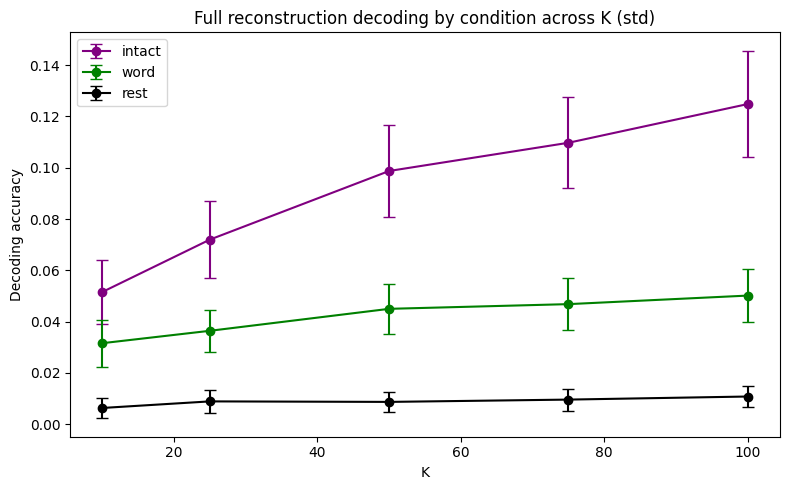

In [16]:

plt.figure(figsize=(8, 5))

for cond_name in ["intact", "word", "rest"]:
    sub = full_summary[full_summary["condition"] == cond_name].sort_values("K")
    plt.errorbar(
        sub["K"],
        sub["mean"],
        yerr=sub["err"],
        marker="o",
        capsize=4,
        color=COND_PLOT_COLORS[cond_name],
        label=cond_name,
    )

plt.xlabel("K")
plt.ylabel("Decoding accuracy")
plt.title(f"Full reconstruction decoding by condition across K ({ERRORBAR_TYPE})")
plt.legend()
plt.tight_layout()
plt.show()


## Plot 2: Top-m global archetype decoding by condition across K

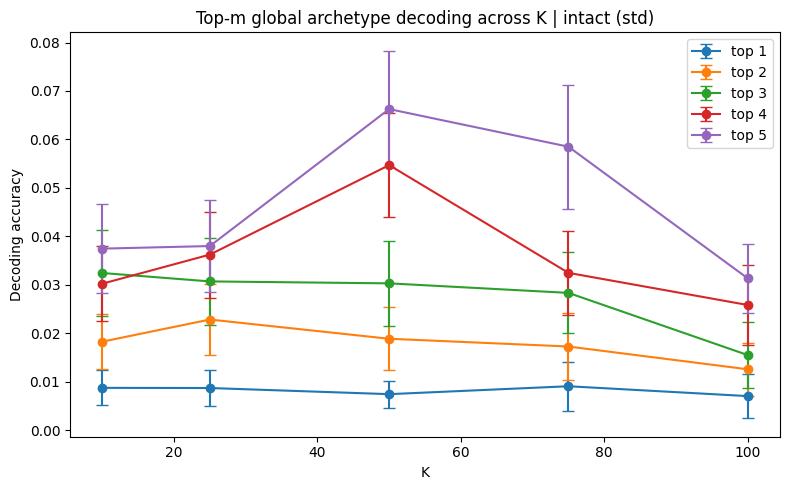

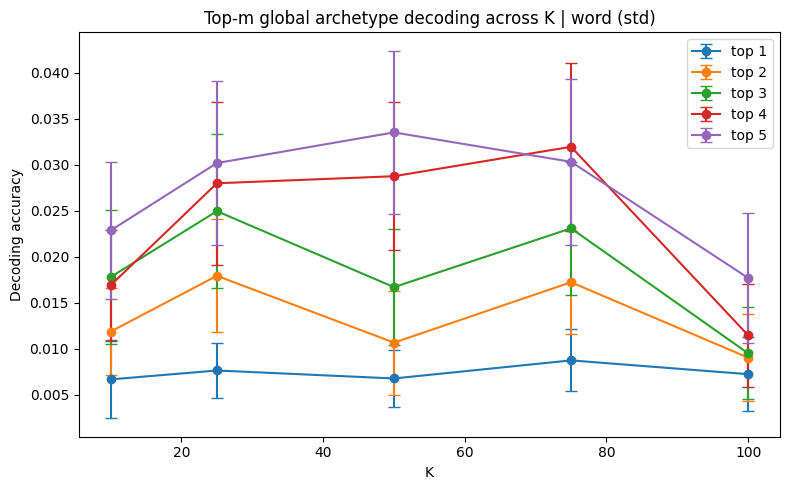

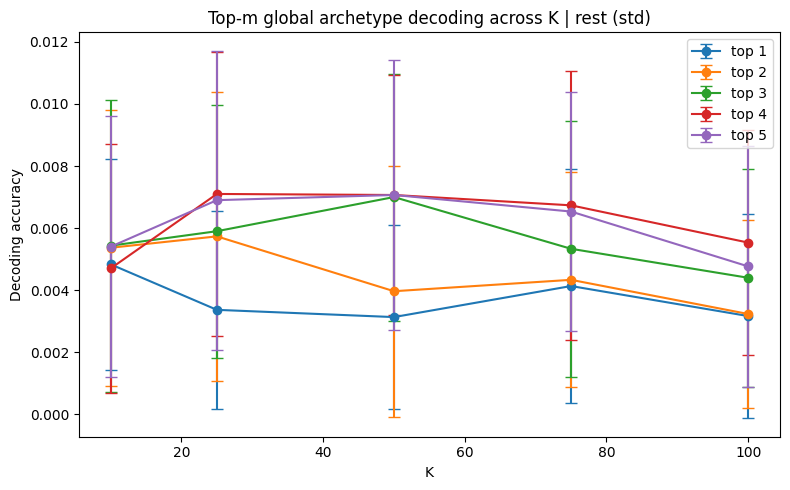

In [17]:

for cond_name in ["intact", "word", "rest"]:
    plt.figure(figsize=(8, 5))
    cond_df = topm_summary[topm_summary["condition"] == cond_name].sort_values(["top_m", "K"])

    for top_m in sorted(cond_df["top_m"].unique()):
        sub = cond_df[cond_df["top_m"] == top_m].sort_values("K")
        plt.errorbar(
            sub["K"],
            sub["mean"],
            yerr=sub["err"],
            marker="o",
            capsize=4,
            label=f"top {top_m}",
        )

    plt.xlabel("K")
    plt.ylabel("Decoding accuracy")
    plt.title(f"Top-m global archetype decoding across K | {cond_name} ({ERRORBAR_TYPE})")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Plot 3: Best top-m global decoding by condition across K

,K,condition,reconstruction,top_m,mean,std,count,err
4,10,intact,top_m_global,5,0.037467,0.009176,100,0.009176
14,10,word,top_m_global,5,0.022867,0.007431,100,0.007431
7,10,rest,top_m_global,3,0.005433,0.004706,100,0.004706
19,25,intact,top_m_global,5,0.038000,0.009523,100,0.009523
29,25,word,top_m_global,5,0.030200,0.008950,100,0.008950
23,25,rest,top_m_global,4,0.007100,0.004585,100,0.004585
34,50,intact,top_m_global,5,0.066267,0.012044,100,0.012044
44,50,word,top_m_global,5,0.033533,0.008887,100,0.008887
38,50,rest,top_m_global,4,0.007067,0.003857,100,0.003857
49,75,intact,top_m_global,5,0.058500,0.012795,100,0.012795


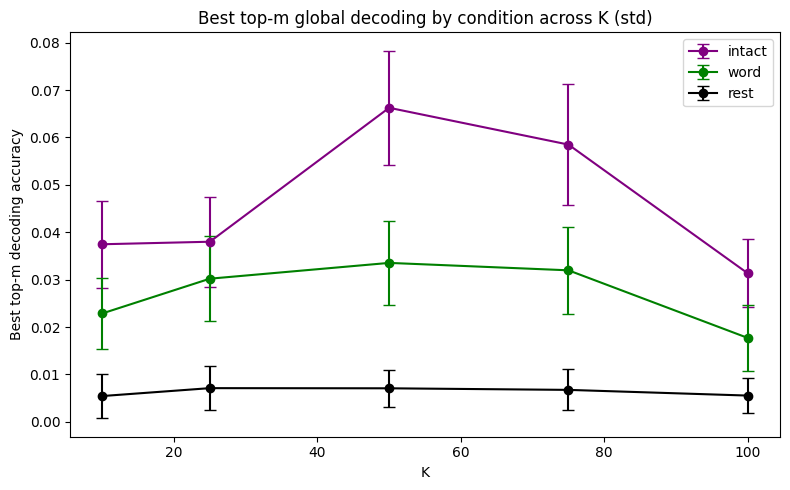

In [18]:

best_topm_rows = []

for K in K_VALUES:
    for cond_name in ["intact", "word", "rest"]:
        sub = topm_summary[(topm_summary["K"] == K) & (topm_summary["condition"] == cond_name)]
        if len(sub) == 0:
            continue
        best_idx = sub["mean"].idxmax()
        best_row = sub.loc[best_idx].copy()
        best_topm_rows.append(best_row)

best_topm_df = pd.DataFrame(best_topm_rows)
display(best_topm_df)

plt.figure(figsize=(8, 5))
for cond_name in ["intact", "word", "rest"]:
    sub = best_topm_df[best_topm_df["condition"] == cond_name].sort_values("K")
    plt.errorbar(
        sub["K"],
        sub["mean"],
        yerr=sub["err"],
        marker="o",
        capsize=4,
        color=COND_PLOT_COLORS[cond_name],
        label=cond_name,
    )

plt.xlabel("K")
plt.ylabel("Best top-m decoding accuracy")
plt.title(f"Best top-m global decoding by condition across K ({ERRORBAR_TYPE})")
plt.legend()
plt.tight_layout()
plt.show()


## Plot 4: Top clustering-archetype decoding by condition across K

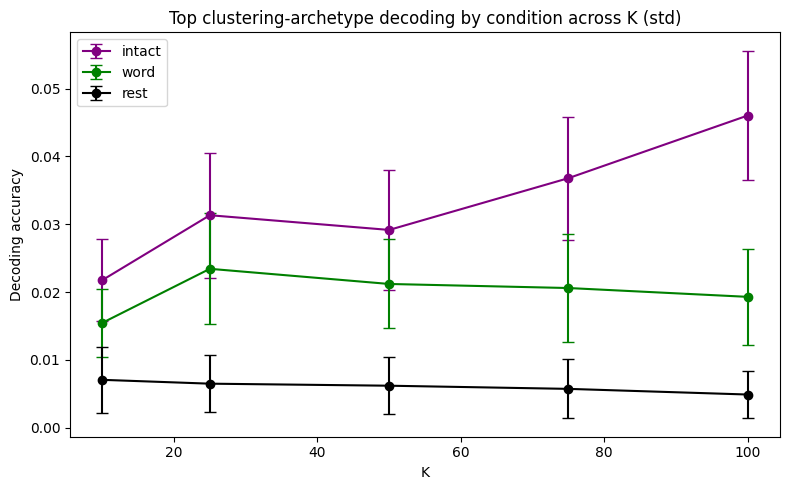

In [19]:

if len(cluster_summary) > 0:
    plt.figure(figsize=(8, 5))

    for cond_name in ["intact", "word", "rest"]:
        sub = cluster_summary[cluster_summary["condition"] == cond_name].sort_values("K")
        plt.errorbar(
            sub["K"],
            sub["mean"],
            yerr=sub["err"],
            marker="o",
            capsize=4,
            color=COND_PLOT_COLORS[cond_name],
            label=cond_name,
        )

    plt.xlabel("K")
    plt.ylabel("Decoding accuracy")
    plt.title(f"Top clustering-archetype decoding by condition across K ({ERRORBAR_TYPE})")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No top clustering archetypes provided yet. Paste TOP_CLUSTER_ARCHES_BY_K above.")


## Plot 5: Compare full reconstruction vs best top-m vs top clustering archetypes

In [20]:

comparison_rows = []

# full reconstruction
for _, row in full_summary.iterrows():
    comparison_rows.append({
        "K": row["K"],
        "condition": row["condition"],
        "analysis": "full_reconstruction",
        "mean": row["mean"],
        "err": row["err"],
    })

# best top-m
for _, row in best_topm_df.iterrows():
    comparison_rows.append({
        "K": row["K"],
        "condition": row["condition"],
        "analysis": f"best_top_m_{int(row['top_m'])}",
        "mean": row["mean"],
        "err": row["err"],
    })

# top clustering archetypes
if len(cluster_summary) > 0:
    for _, row in cluster_summary.iterrows():
        comparison_rows.append({
            "K": row["K"],
            "condition": row["condition"],
            "analysis": "top_cluster_archetypes",
            "mean": row["mean"],
            "err": row["err"],
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.head(20))


,K,condition,analysis,mean,err
0,10,intact,full_reconstruction,0.051533,0.012304
1,10,rest,full_reconstruction,0.006300,0.004045
2,10,word,full_reconstruction,0.031567,0.009094
3,25,intact,full_reconstruction,0.071967,0.015065
4,25,rest,full_reconstruction,0.008867,0.004599
5,25,word,full_reconstruction,0.036400,0.008270
6,50,intact,full_reconstruction,0.098733,0.017757
7,50,rest,full_reconstruction,0.008667,0.003761
8,50,word,full_reconstruction,0.044967,0.009681
9,75,intact,full_reconstruction,0.109733,0.017801


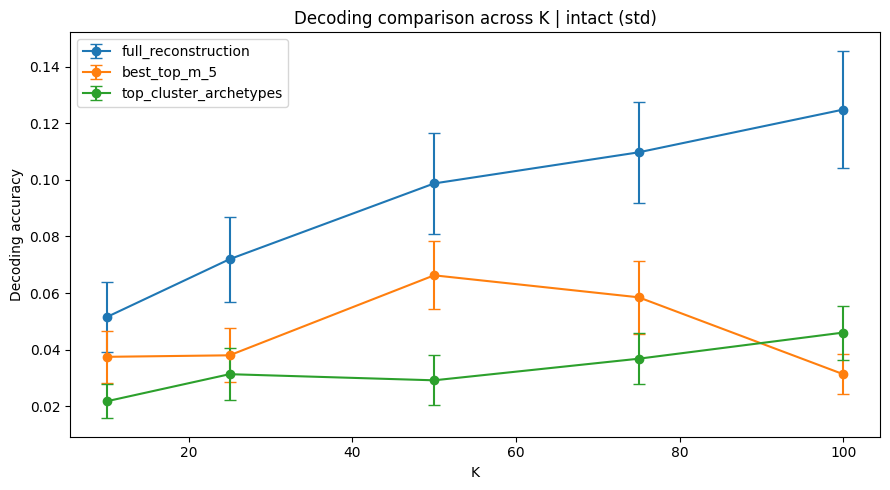

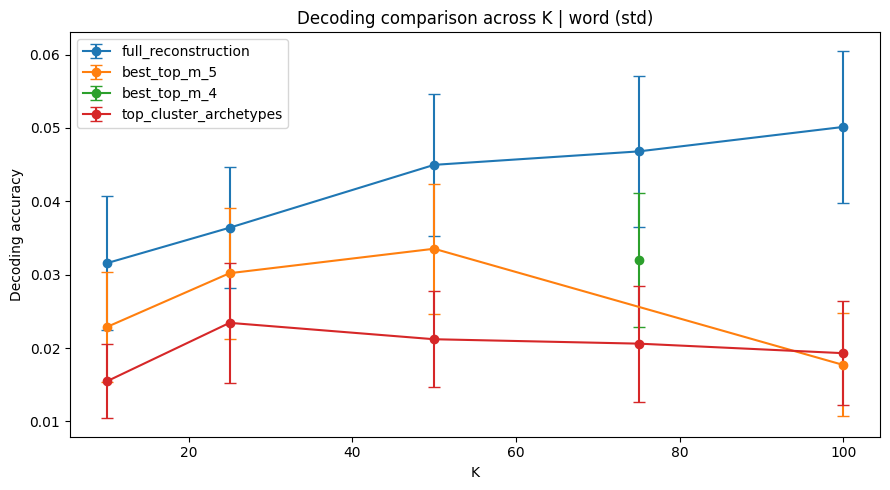

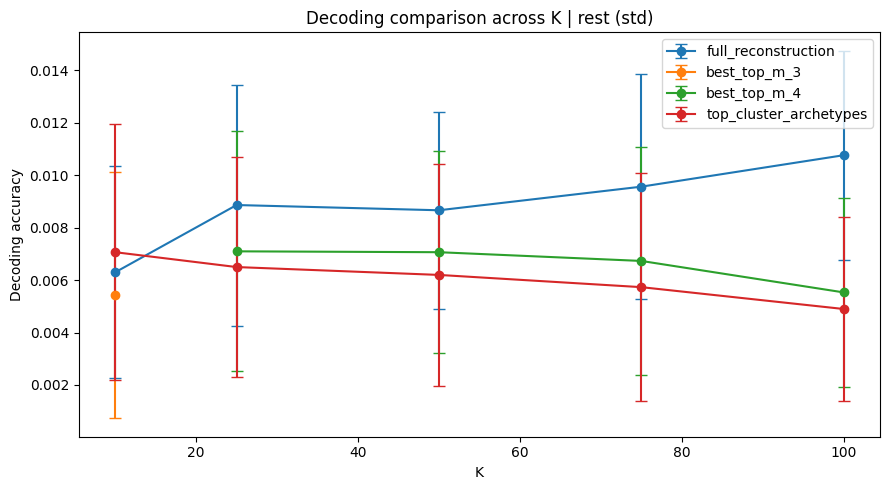

In [21]:

for cond_name in ["intact", "word", "rest"]:
    plt.figure(figsize=(9, 5))
    sub = comparison_df[comparison_df["condition"] == cond_name]

    for analysis_name in sub["analysis"].unique():
        cur = sub[sub["analysis"] == analysis_name].sort_values("K")
        plt.errorbar(
            cur["K"],
            cur["mean"],
            yerr=cur["err"],
            marker="o",
            capsize=4,
            label=analysis_name,
        )

    plt.xlabel("K")
    plt.ylabel("Decoding accuracy")
    plt.title(f"Decoding comparison across K | {cond_name} ({ERRORBAR_TYPE})")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Optional: save summaries

In [22]:

OUTPUT_SUMMARY_DIR = "decoding_summaries"
os.makedirs(OUTPUT_SUMMARY_DIR, exist_ok=True)

full_recon_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "full_reconstruction_runs.csv"), index=False)
topm_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "topm_runs.csv"), index=False)

if len(cluster_recon_df) > 0:
    cluster_recon_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "top_cluster_runs.csv"), index=False)

full_summary.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "full_reconstruction_summary.csv"), index=False)
topm_summary.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "topm_summary.csv"), index=False)

if len(cluster_summary) > 0:
    cluster_summary.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "top_cluster_summary.csv"), index=False)

comparison_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "comparison_summary.csv"), index=False)
topm_archetypes_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "topm_archetype_identities.csv"), index=False)
best_topm_selection_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "best_topm_selection_by_condition.csv"), index=False)

# Machine-readable outputs
np.save(os.path.join(OUTPUT_SUMMARY_DIR, "global_rankings_by_K.npy"), global_rankings, allow_pickle=True)

best_topm_dict = {}
for _, row in best_topm_selection_df.iterrows():
    K = int(row["K"])
    if K not in best_topm_dict:
        best_topm_dict[K] = {}
    best_topm_dict[K][row["condition"]] = {
        "best_top_m": int(row["best_top_m"]),
        "selected_archetypes": row["selected_archetypes"],
        "mean_accuracy": float(row["mean_accuracy"]),
        "err": float(row["err"]),
    }

np.save(os.path.join(OUTPUT_SUMMARY_DIR, "best_topm_selection_by_condition.npy"), best_topm_dict, allow_pickle=True)

print("Saved summaries to:", OUTPUT_SUMMARY_DIR)


Saved summaries to: decoding_summaries
